In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [52]:
df = pd.read_csv( "CC Preprocessed.csv" )

In [53]:
log_columns = ['BALANCE' ,'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE' , 
               'CASH_ADVANCE_TRX', 'PURCHASES_TRX','CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS' ]
df_unscaled=df.copy()
df_unscaled[log_columns] = df[log_columns].map(lambda x : np.expm1(x))
 

got the unscaled version back to help visualize on charts with original numbers 

In [ ]:
df.head()

,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.818182,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12
1,8.071989,0.909091,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12
2,7.822504,1.000000,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12
3,7.419183,0.636364,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,0.693147,0.693147,8.922792,0.000000,6.619300,0.000000,12
4,6.707735,1.000000,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12


# Visualizing Clusters usin T-SNE


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 8950 samples in 0.002s...
[t-SNE] Computed neighbors for 8950 samples in 1.105s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8950
[t-SNE] Computed conditional probabilities for sample 2000 / 8950
[t-SNE] Computed conditional probabilities for sample 3000 / 8950
[t-SNE] Computed conditional probabilities for sample 4000 / 8950
[t-SNE] Computed conditional probabilities for sample 5000 / 8950
[t-SNE] Computed conditional probabilities for sample 6000 / 8950
[t-SNE] Computed conditional probabilities for sample 7000 / 8950
[t-SNE] Computed conditional probabilities for sample 8000 / 8950
[t-SNE] Computed conditional probabilities for sample 8950 / 8950
[t-SNE] Mean sigma: 0.763304
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.413254
[t-SNE] KL divergence after 500 iterations: 1.358171


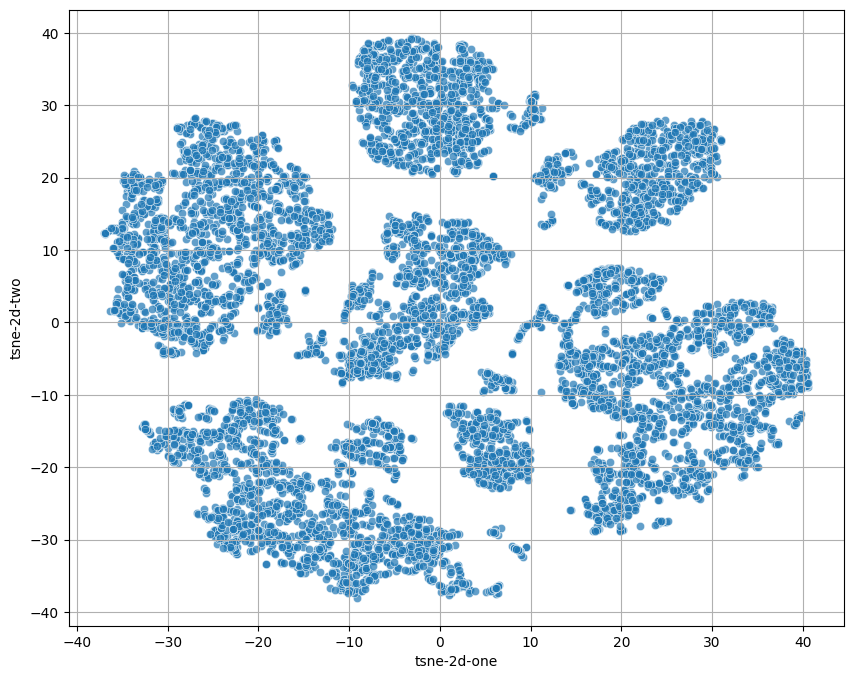

In [ ]:
tsne_model = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=500)
tsne_results = tsne_model.fit_transform(df)
df['tsne-2d-one'] = tsne_results[:,0]
df['tsne-2d-two'] = tsne_results[:,1] 
plt.figure(figsize=(10,8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two", 
    data=df,
    legend="full",
    alpha=0.7
)
plt.grid(True)
plt.show()

we infer from this plot that we should cluster into 6-7 clusters 

we will check using k-mean elbow test to choose K

In [ ]:
df.drop(['tsne-2d-one','tsne-2d-two'],axis = 1 ,inplace=True)

# K-Means Test

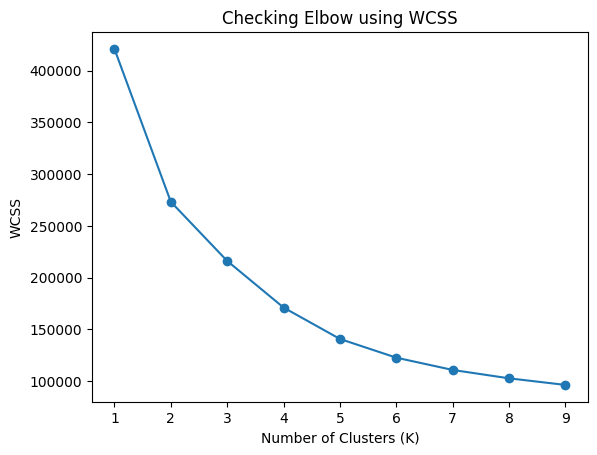

In [ ]:

wcss=[]
for k in range (1,10):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init =15)
    kmeans.fit(df.values)
    wcss.append(kmeans.inertia_)
plt.plot(range (1,10),wcss,marker ='o')
plt.title("Checking Elbow using WCSS")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow is somewhat smooth but there isnt big change since 6 so i will pick 6 

# K-Means Clustering

In [6]:
df_kmeans = df.copy()
kmeans = KMeans(n_clusters=6,random_state=42,n_init ='auto')
labels = kmeans.fit_predict(df_kmeans)
df_kmeans['cluster'] = labels


C:\Users\sokar\AppData\Local\Temp\ipykernel_10500\654417505.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_kmeans,x='cluster',palette='tab10')


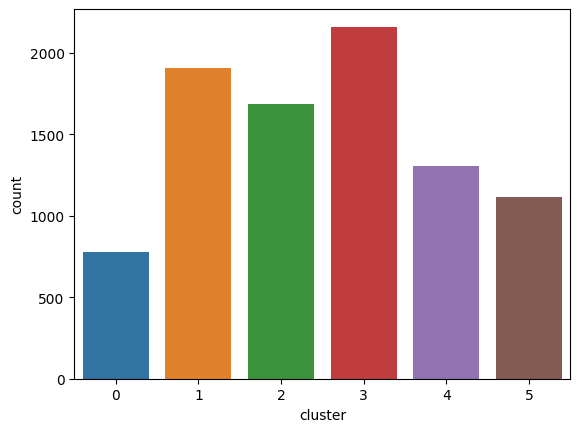

In [9]:
sns.countplot(data=df_kmeans,x='cluster',palette='tab10')
plt.show()

we can see each cluster has fair amount of points

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 8950 samples in 0.001s...
[t-SNE] Computed neighbors for 8950 samples in 0.855s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8950
[t-SNE] Computed conditional probabilities for sample 2000 / 8950
[t-SNE] Computed conditional probabilities for sample 3000 / 8950
[t-SNE] Computed conditional probabilities for sample 4000 / 8950
[t-SNE] Computed conditional probabilities for sample 5000 / 8950
[t-SNE] Computed conditional probabilities for sample 6000 / 8950
[t-SNE] Computed conditional probabilities for sample 7000 / 8950
[t-SNE] Computed conditional probabilities for sample 8000 / 8950
[t-SNE] Computed conditional probabilities for sample 8950 / 8950
[t-SNE] Mean sigma: 0.764438
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.370697
[t-SNE] KL divergence after 500 iterations: 1.354170


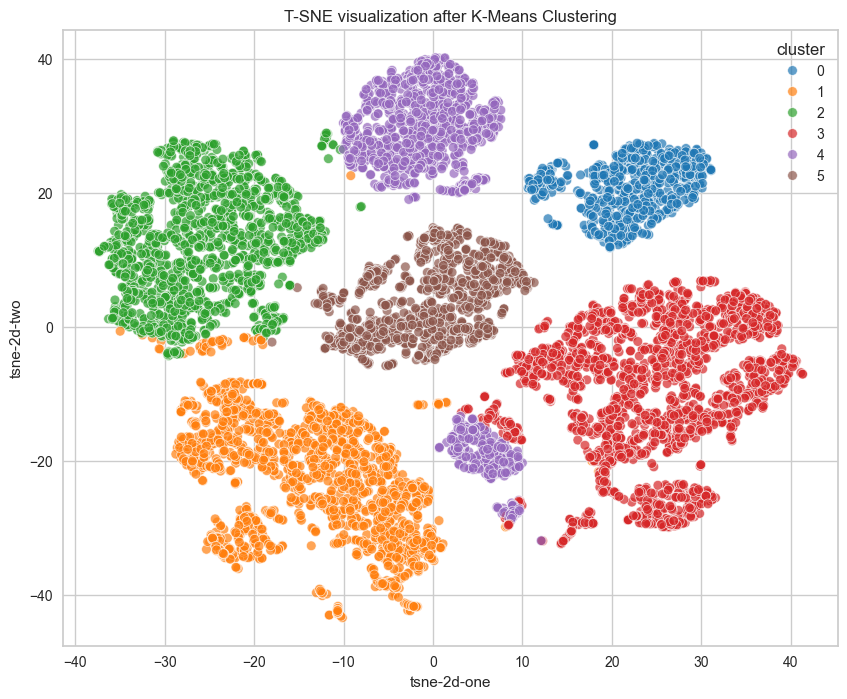

In [53]:
tsne_model = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=500)
tsne_results = tsne_model.fit_transform(df_kmeans)
df_kmeans['tsne-2d-one'] = tsne_results[:,0]
df_kmeans['tsne-2d-two'] = tsne_results[:,1] 
plt.figure(figsize=(10,8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two", hue='cluster',palette='tab10',
    data=df_kmeans,
    legend="full",
    alpha=0.7
)
plt.grid(True)
plt.title('T-SNE visualization after K-Means Clustering')
plt.show()

According to this visual k-means shows good clustering and 6 clusters seems like a good choice for this data

In [19]:
cols = df.columns
df_unscaled['labels'] = df_kmeans['cluster']


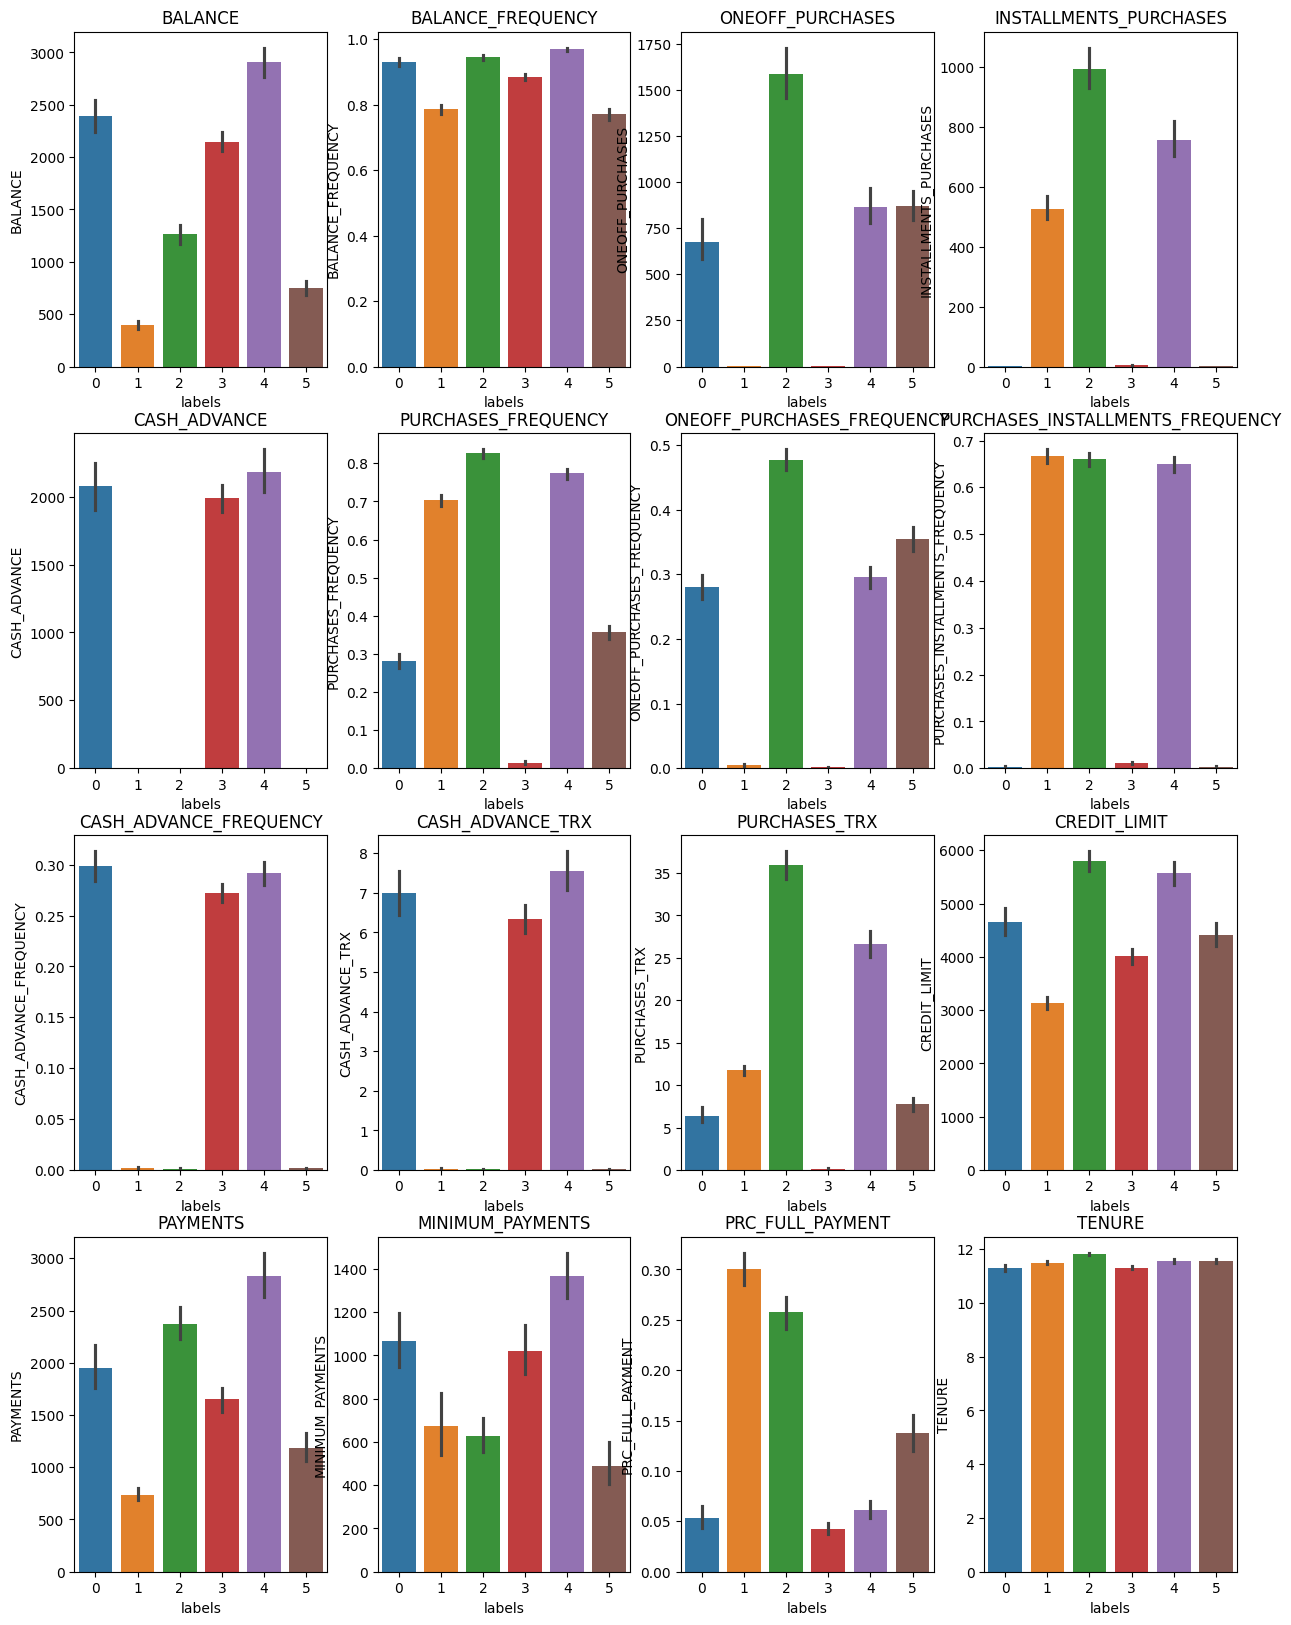

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(15, 20))
axes = axes.flatten()
for i,col in enumerate(cols):
    sns.barplot(data = df_unscaled,x='labels',y=col,hue='labels',ax=axes[i],palette="tab10",legend=False)
    axes[i].set_title(col)
    
 



<span style="color:blue">Cluster 0 </span> & <span style="color:red">Cluster 3 </span>: The Cash Advance Dependents
Both clusters show a heavy reliance on cash advances (CASH_ADVANCE, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX)
and carry moderate-to-high balances. Conversely, they exhibit almost zero engagement with direct card purchases

but cluster 0  makes higher payments than Cluster 3

<span style="color:orange">Cluster 1</span>:The Responsible Installment Shoppers

This group has the lowest overall BALANCE and strictly avoids cash advances. However, they use their cards frequently (PURCHASES_FREQUENCY is high), almost entirely driven by installment purchases

<span style="color:lightgreen">Cluster 2</span>: The Premium Power Users

This is your most lucrative and active segment. They boast the highest CREDIT_LIMIT and dominate all purchase-related metrics: ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, and PURCHASES_TRX. Like Cluster 1, they avoid cash advances.

<span style="color:purple">Cluster 4</span>: The Maximum Utilizers (High Engagement / High Debt)

This cluster maxes out nearly every metric. They have the highest BALANCE, highest BALANCE_FREQUENCY, and the highest CASH_ADVANCE metrics.

<span style="color:brown">Cluster 5:</span>: The Occasional / One-Off Users

this group has generally low engagement. They have low balances, low credit limits, and zero installment purchases. When they do use the card, it is strictly for occasional one-off transactions

In [55]:
df_unscaled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE', 'labels'],
      dtype='object')

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler

 
np.random.seed(42)


 


 
features_to_plot = [
    'BALANCE', 'CREDIT_LIMIT', 'ONEOFF_PURCHASES', 
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PAYMENTS'
]

 
scaler = MinMaxScaler()
df_scaled = df_unscaled.copy()
df_scaled[features_to_plot] = scaler.fit_transform(df[features_to_plot])

 
cluster_centroids = df_scaled.groupby('labels')[features_to_plot].mean().reset_index()

 
clusters = cluster_centroids['labels'].unique()
num_clusters = len(clusters)

 
fig = make_subplots(
    rows=1, cols=num_clusters, 
    specs=[[{'type': 'polar'}] * num_clusters],
    subplot_titles=[f"Cluster {c} Profile" for c in clusters]
)

for i, cluster in enumerate(clusters):

    row = cluster_centroids[cluster_centroids['labels'] == cluster].iloc[0]
    values = row[features_to_plot].tolist()
    
 
    values_closed = values + [values[0]]
    categories_closed = features_to_plot + [features_to_plot[0]]
    
    # Add the Scatterpolar trace
    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=categories_closed,
            fill='toself',           
            name=f'Cluster {cluster}',
            line=dict(width=2),
            marker=dict(size=6)
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text="Cluster Profiles (Normalized Feature Means)",
    showlegend=False,  
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    polar2=dict(radialaxis=dict(visible=True, range=[0, 1])),
    polar3=dict(radialaxis=dict(visible=True, range=[0, 1])),
    height=500,
    width=400 * num_clusters
)

fig.show()

This radar plot shows exactly what each cluster excels in and on it and the barplots i put the previous insights

# GMM

In [54]:
from sklearn.mixture import GaussianMixture
df_gmm = df.copy()
gmm = GaussianMixture(n_components=6,random_state=42)
df_gmm['labels'] = gmm.fit_predict(df.values)


C:\Users\sokar\AppData\Local\Temp\ipykernel_10500\3778859766.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_gmm,x='labels',palette='tab10')


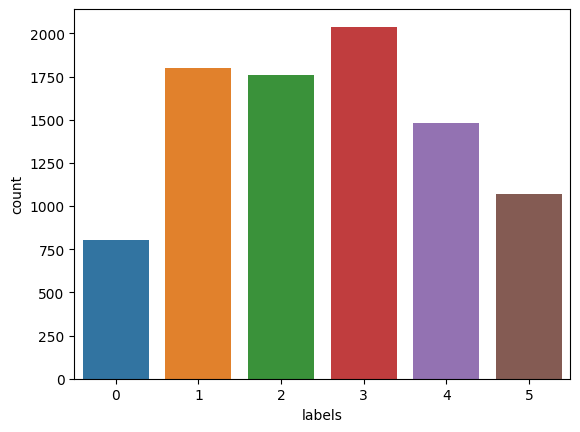

In [12]:
sns.countplot(data=df_gmm,x='labels',palette='tab10')
plt.show()

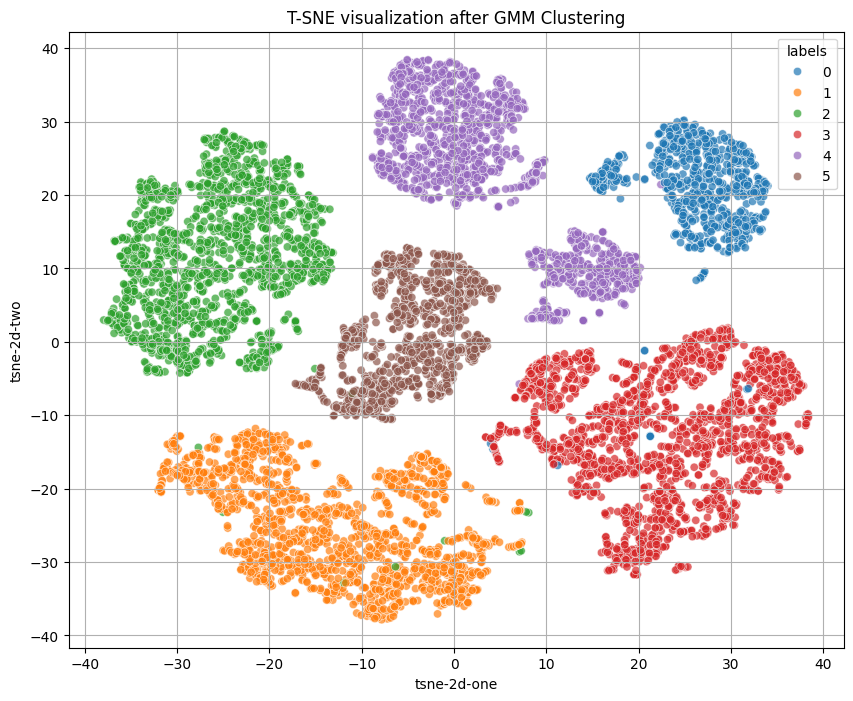

In [32]:
tsne_model = TSNE(n_components=2, perplexity=40, max_iter=500)
tsne_results = tsne_model.fit_transform(df_gmm)
df_gmm['tsne-2d-one'] = tsne_results[:,0]
df_gmm['tsne-2d-two'] = tsne_results[:,1] 
plt.figure(figsize=(10,8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two", hue='labels',palette='tab10',
    data=df_gmm,
    legend="full",
    alpha=0.7
)
plt.grid(True)
plt.title('T-SNE visualization after GMM Clustering')
plt.show()

The visualization using tsne shows 6 clusters fitting well to data always 


Clustering is more dense than Kmeans here


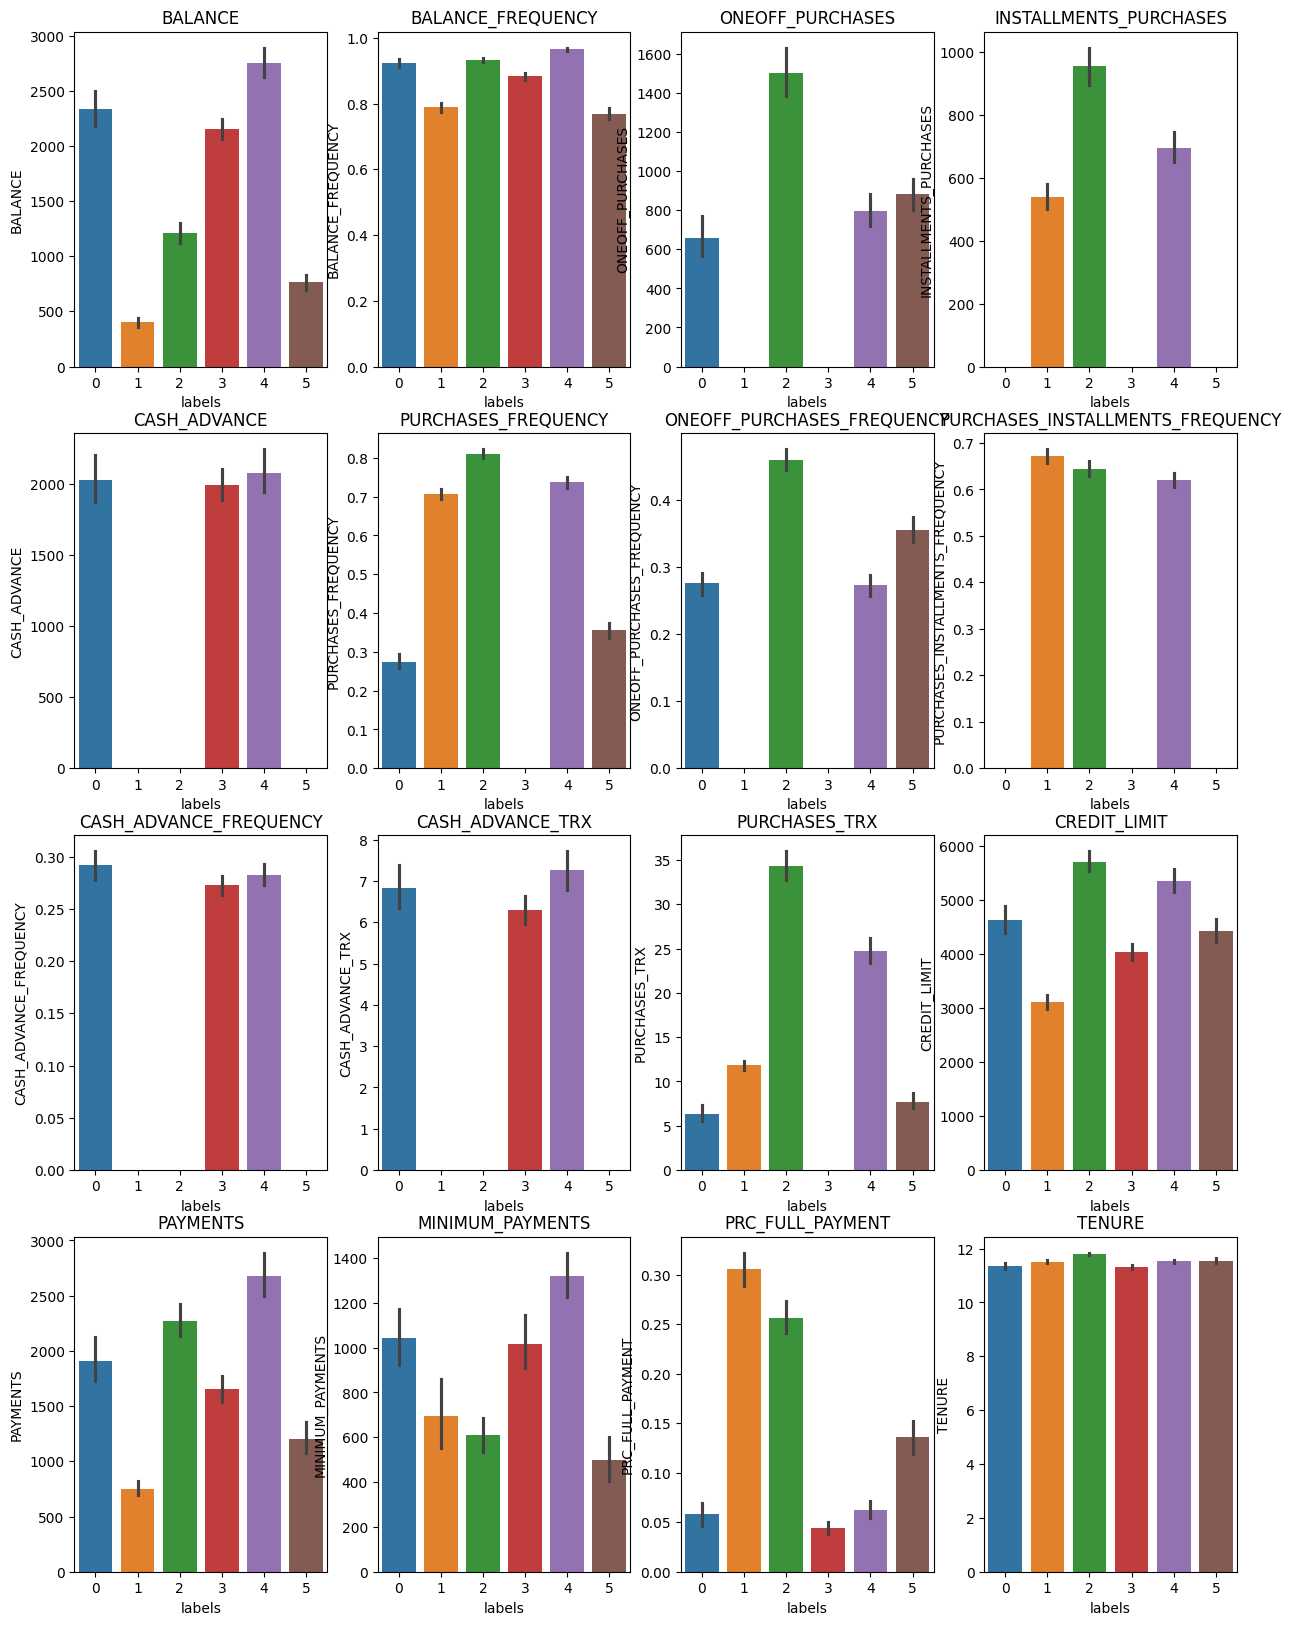

In [58]:
df_unscaled['labels']  = df_gmm['labels']
fig, axes = plt.subplots(4, 4, figsize=(15, 20))
axes = axes.flatten()
for i,col in enumerate(df.columns):
    sns.barplot(data = df_unscaled,x=df_unscaled['labels'],y=col,hue=df_unscaled['labels'],ax=axes[i],palette="tab10",legend=False)
    axes[i].set_title(col)

GMMs shows close insights to that in K-means which is mentioned thoroughly in report

In [ ]:
np.random.seed(42)

features_to_plot = [
    'BALANCE', 'CREDIT_LIMIT', 'ONEOFF_PURCHASES', 
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PAYMENTS'
]

 
df_scaled['labels'] = df_gmm['labels']
cluster_centroids = df_scaled.groupby('labels')[features_to_plot].mean().reset_index()

 
clusters = cluster_centroids['labels'].unique()
num_clusters = len(clusters)

 
fig = make_subplots(
    rows=1, cols=num_clusters, 
    specs=[[{'type': 'polar'}] * num_clusters],
    subplot_titles=[f"Cluster {c} Profile" for c in clusters]
)

for i, cluster in enumerate(clusters):

    row = cluster_centroids[cluster_centroids['labels'] == cluster].iloc[0]
    values = row[features_to_plot].tolist()
    
 
    values_closed = values + [values[0]]
    categories_closed = features_to_plot + [features_to_plot[0]]
    
    # Add the Scatterpolar trace
    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=categories_closed,
            fill='toself',           
            name=f'Cluster {cluster}',
            line=dict(width=2),
            marker=dict(size=6)
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text="Cluster Profiles (Normalized Feature Means)",
    showlegend=False,  
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    polar2=dict(radialaxis=dict(visible=True, range=[0, 1])),
    polar3=dict(radialaxis=dict(visible=True, range=[0, 1])),
    height=500,
    width=400 * num_clusters
)

fig.show()

This is talked about thorughly in report